In [1]:
import sys
import json
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether launched from repo root or Notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "backtesting" / "renquant_102").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import common

# ── Strategy configuration ───────────────────────────────────────────────
STRATEGY_DIR = repo_root / "backtesting" / "renquant_102"
MODELS_DIR = STRATEGY_DIR / "models"
config = common.load_strategy_config(STRATEGY_DIR / "strategy_config.json")

WATCHLIST = config["watchlist"]
BENCHMARK = config.get("benchmark", "SPY")
MODEL_NAME = config["model_name"]
PROVIDER = config["data_src"]

# Dynamic 2-year window ending today
END = str(date.today())
START = str(date.today() - timedelta(days=365 * int(config.get("training_years", 2))))

# Full indicator spec — all available indicators computed upfront.
INDICATOR_SPEC = {
    "rsi":         {"period": 14},
    "macd":        {"fast": 12, "slow": 26, "signal": 9},
    "cci":         {"period": 20},
    "bbp":         {"period": 20},
    "stochastic":  {"window": 14, "smooth": 3},
    "adx":         {"period": 14},
    "atr":         {"period": 14},
    "obv":         {"signal_period": 20},
    "williams_r":  {"period": 14},
    "ema":         {"period": 50},
    "momentum":    {"period": 10},
}

# Shared feature columns for Classification and Mean Reversion models.
FEATURE_COLUMNS = ["rsi", "macd_hist", "cci", "bbp", "adx", "williams_r", "obv_slope"]
RATIO_FEATURES = {"rsi", "adx"}
DIFF_FEATURES  = {"macd_hist", "cci", "bbp", "williams_r", "obv_slope"}

# Q-Learning uses same relative indicator features as Classification (first 5)
QL_FEATURE_COLUMNS = FEATURE_COLUMNS[:5]  # ["rsi", "macd_hist", "cci", "bbp", "adx"]

# ── Simulation parameters (from config) ──────────────────────────────────
INITIAL_CASH = 10_000
WASH_SALE_DAYS = config.get("wash_sale_days", 30)
MIN_HOLD_DAYS = config.get("min_hold_days", 20)
MAX_HOLD_DAYS = config.get("max_hold_days", 150)
TRAIN_SPLIT    = config.get("train_split", 0.70)
pos_sizing = config.get("position_sizing", {})
MAX_POSITION_PCT = pos_sizing.get("max_position_pct", 0.33)
CASH_RESERVE_PCT = pos_sizing.get("cash_reserve_pct", 0.10)

# ── Approach configurations ──────────────────────────────────────────────
DUAL_MOM_RULES = [
    {"col": "trend",       "buy_above": 1.0,    "sell_below": 0.97},
    {"col": "trend_long",  "buy_above": 1.0,    "sell_below": 0.97},
    {"col": "rel_mom_20d", "buy_above": 0.0,    "sell_below": -0.03},
    {"col": "rel_mom_60d", "buy_above": 0.0,    "sell_below": -0.05},
    {"col": "macd_hist",   "buy_above": 0,       "sell_below": 0},
    {"col": "obv_slope",   "buy_above": 0,       "sell_below": 0},
]

MR_RULES = [
    {"col": "rsi",        "buy_below": 0.9,    "sell_above": 1.1},
    {"col": "bbp",        "buy_below": -0.2,   "sell_above": 0.3},
    {"col": "williams_r", "buy_below": -20,    "sell_above": 20},
    {"col": "trend",      "buy_below": 0.98,   "sell_above": 1.05},
    {"col": "cci",        "buy_below": -30,    "sell_above": 50},
]

CLASSIFICATION_PARAMS = {
    "feature_columns": FEATURE_COLUMNS,
    "lookahead": 5,
    "threshold": 0.03,
    "leaf_size": 25,
    "bags": 15,
    "buy_threshold": 0.1,
    "sell_threshold": -0.1,
}

QLEARNING_PARAMS = {
    "feature_columns": QL_FEATURE_COLUMNS,
    "n_bins": 5,
    "n_epochs": 500,
    "alpha": 0.15,
    "gamma": 0.95,
    "rar": 0.99,
    "radr": 0.9995,
    "dyna": 0,
}

print(f"Strategy:  {MODEL_NAME}")
print(f"Watchlist: {len(WATCHLIST)} symbols")
print(f"Window:    {START} -> {END}")
print(f"Benchmark: {BENCHMARK}")
print(f"Approaches: Dual Momentum, Classification, Q-Learning, Mean Reversion")

Strategy:  renquant-102
Watchlist: 21 symbols
Window:    2023-04-12 -> 2026-04-11
Benchmark: SPY
Approaches: Dual Momentum, Classification, Q-Learning, Mean Reversion


In [2]:
# ── Fetch OHLCV + compute indicators for all watchlist stocks + SPY ──────
all_symbols = list(set(WATCHLIST + [BENCHMARK]))
dfs_raw = {}
dfs_ind = {}

for sym in all_symbols:
    print(f"  Fetching {sym}...", end=" ")
    try:
        raw = common.fetch_ohlcv(sym, start=START, end=END, provider=PROVIDER)
        ind = common.compute_indicators(raw, INDICATOR_SPEC)
        dfs_raw[sym] = raw
        dfs_ind[sym] = ind
        print(f"{len(raw)} bars")
    except Exception as e:
        print(f"FAILED: {e}")

df_spy = dfs_ind[BENCHMARK]
print(f"\nFetched {len(dfs_ind)} / {len(all_symbols)} symbols")

  Fetching XLF... 752 bars
  Fetching CRM... 752 bars
  Fetching SPY... 752 bars
  Fetching LLY... 752 bars
  Fetching TSLA... 752 bars
  Fetching XLE... 752 bars
  Fetching JPM... 752 bars
  Fetching XOM... 752 bars
  Fetching BA... 752 bars
  Fetching AMZN... 752 bars
  Fetching GOOG... 752 bars
  Fetching SHOP... 750 bars
  Fetching NVDA... 752 bars
  Fetching COIN... 750 bars
  Fetching NFLX... 752 bars
  Fetching UBER... 752 bars
  Fetching AMD... 752 bars
  Fetching CAT... 752 bars
  Fetching PLTR... 752 bars
  Fetching UNH... 752 bars
  Fetching ARKK... 750 bars
  Fetching MSFT... 752 bars

Fetched 22 / 22 symbols


In [3]:
# ── Build per-symbol relative feature frames ────────────────────────────
# For each watchlist stock, compute:
# - Relative indicator features vs SPY (for Classification, Mean Reversion)
# - Trend features (for Dual Momentum, Q-Learning)
# - Q-Learning variant with rel_price as "close" for relative reward

stock_features = {}    # {symbol: DataFrame with all features}
stock_features_ql = {} # {symbol: DataFrame for Q-Learning (rel_price as close)}
skipped = []

for symbol in WATCHLIST:
    if symbol not in dfs_ind:
        skipped.append(symbol)
        continue

    df_stock = dfs_ind[symbol]

    # Align trading days
    common_idx = df_stock.index.intersection(df_spy.index)
    if len(common_idx) < 100:
        skipped.append(symbol)
        continue

    s = df_stock.loc[common_idx]
    b = df_spy.loc[common_idx]

    df = pd.DataFrame(index=common_idx)
    df["close"] = s["close"]
    df["close_spy"] = b["close"]
    df["rel_price"] = s["close"] / b["close"]

    # Relative indicator features
    for col in FEATURE_COLUMNS:
        if col in RATIO_FEATURES:
            df[col] = s[col] / b[col].replace(0, np.nan)
        else:
            df[col] = s[col] - b[col]

    # Trend-following features
    df["trend"] = s["close"] / s["close"].ewm(span=50, adjust=False).mean()
    df["trend_long"] = s["close"] / s["close"].ewm(span=200, adjust=False).mean()
    df["rel_mom_20d"] = df["rel_price"].pct_change(20)
    df["rel_mom_60d"] = df["rel_price"].pct_change(60)

    df = df.dropna()
    if len(df) < 100:
        skipped.append(symbol)
        continue

    stock_features[symbol] = df

    # Q-Learning variant: rel_price as "close" for relative reward
    df_ql = df[["rel_price", *QL_FEATURE_COLUMNS]].copy()
    df_ql = df_ql.rename(columns={"rel_price": "close"})
    stock_features_ql[symbol] = df_ql

print(f"Built features for {len(stock_features)} symbols")
if skipped:
    print(f"Skipped (insufficient data): {skipped}")

Built features for 21 symbols


/var/folders/xz/ry162rh91998lc0yc5knbsqc0000gp/T/ipykernel_5558/2477969702.py:42: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["rel_mom_20d"] = df["rel_price"].pct_change(20)
/var/folders/xz/ry162rh91998lc0yc5knbsqc0000gp/T/ipykernel_5558/2477969702.py:43: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["rel_mom_60d"] = df["rel_price"].pct_change(60)
/var/folders/xz/ry162rh91998lc0yc5knbsqc0000gp/T/ipykernel_5558/2477969702.py:42: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values 

In [4]:
# ── Helper functions: constraints + equity simulation ────────────────────
# Same logic as renquant_101 — single-stock simulation for model comparison.

# ── Tax configuration ────────────────────────────────────────────────────
TAX_CONFIG = common.load_tax_config(config)
print(f"Tax config: short-term {TAX_CONFIG['short_term_rate']:.0%} "
      f"(< {TAX_CONFIG['long_term_threshold_days']}d), "
      f"long-term {TAX_CONFIG['long_term_rate']:.0%}")
if MAX_HOLD_DAYS < TAX_CONFIG["long_term_threshold_days"]:
    print(f"NOTE: max_hold_days={MAX_HOLD_DAYS} < {TAX_CONFIG['long_term_threshold_days']}d "
          f"=> ALL trades are short-term ({TAX_CONFIG['short_term_rate']:.0%} tax)")


def apply_constraints(signals, min_hold_days=0, wash_sale_days=0, max_hold_days=0):
    """Filter raw signals to enforce holding period, max hold, and wash-sale rules."""
    out = signals.values.copy()
    dates = signals.index
    position = 0
    entry_idx = None
    last_sell_idx = None

    for i in range(len(out)):
        sig = out[i]

        if position == 1 and max_hold_days > 0 and entry_idx is not None:
            if (dates[i] - dates[entry_idx]).days >= max_hold_days:
                out[i] = "sell"
                position = 0
                last_sell_idx = i
                entry_idx = None
                continue

        if sig == "buy" and position == 0:
            if last_sell_idx is not None and (dates[i] - dates[last_sell_idx]).days < wash_sale_days:
                out[i] = "hold"
                continue
            position = 1
            entry_idx = i
        elif sig == "sell" and position == 1:
            if entry_idx is not None and (dates[i] - dates[entry_idx]).days < min_hold_days:
                out[i] = "hold"
                continue
            position = 0
            last_sell_idx = i
            entry_idx = None
        else:
            if (sig == "sell" and position == 0) or (sig == "buy" and position == 1):
                out[i] = "hold"
    return pd.Series(out, index=signals.index)


def simulate_equity(signals, prices, initial_cash=INITIAL_CASH,
                    max_position_pct=MAX_POSITION_PCT,
                    cash_reserve_pct=CASH_RESERVE_PCT,
                    tax_config=None):
    """Simulate a long-only equity curve with position sizing and optional tax."""
    close = prices.values
    sigs = signals.values
    cash = float(initial_cash)
    shares = 0
    equity = np.empty(len(sigs))
    trades = []
    entry_idx = None
    entry_price = 0.0

    for i in range(len(sigs)):
        p = close[i]
        portfolio_value = cash + shares * p

        if sigs[i] == "buy" and shares == 0:
            max_invest = portfolio_value * max_position_pct
            available = cash - portfolio_value * cash_reserve_pct
            invest_amount = min(max_invest, max(available, 0))
            shares = int(invest_amount // p)
            cash -= shares * p
            entry_idx = i
            entry_price = p
        elif sigs[i] == "sell" and shares > 0:
            gross_pnl = shares * (p - entry_price)
            holding_days = (signals.index[i] - signals.index[entry_idx]).days if entry_idx is not None else 0
            tax = 0.0
            if tax_config is not None:
                tax = common.compute_trade_tax(
                    gross_pnl, holding_days,
                    tax_config["short_term_rate"],
                    tax_config["long_term_rate"],
                    tax_config["long_term_threshold_days"],
                )
            cash += shares * p - tax
            shares = 0
            if entry_idx is not None:
                trades.append((signals.index[entry_idx], signals.index[i],
                               gross_pnl, tax, holding_days))
                entry_idx = None

        equity[i] = cash + shares * p
    return pd.Series(equity, index=signals.index), trades


def compute_sharpe(equity):
    """Annualized Sharpe ratio from an equity series."""
    daily_rets = equity.pct_change().dropna()
    if daily_rets.std() == 0:
        return 0.0
    return daily_rets.mean() / daily_rets.std() * np.sqrt(252)


print("Helper functions defined: apply_constraints, simulate_equity, compute_sharpe")

Tax config: short-term 50% (< 365d), long-term 32%
Helper functions defined: apply_constraints, simulate_equity, compute_sharpe


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# Per-symbol training loop: 3 approaches, pick best by OOS after-tax Sharpe
# ══════════════════════════════════════════════════════════════════════════
# For each symbol, train on the first TRAIN_SPLIT fraction of data,
# evaluate on the remaining OOS fraction — same methodology as renquant_103.

import random as _random

results = {}  # {symbol: {approach_name: {model, sharpe, return, trades, ...}}}

for i, symbol in enumerate(sorted(stock_features.keys())):
    df     = stock_features[symbol]
    df_ql  = stock_features_ql[symbol]

    # Train / OOS split
    n_train = int(len(df) * TRAIN_SPLIT)
    train_df    = df.iloc[:n_train]
    oos_df      = df.iloc[n_train:]
    train_ql    = df_ql.iloc[:n_train]
    oos_ql      = df_ql.iloc[n_train:]

    if n_train < 60 or len(oos_df) < 30:
        print(f"[{i+1:2d}] {symbol}: insufficient data ({len(df)} rows), skipping")
        continue

    approaches = {}

    # 1. Dual Momentum — train on full training window, evaluate OOS
    dm_model = common.create_model("manual", score_rules=DUAL_MOM_RULES,
                                   buy_threshold=4, sell_threshold=-3)
    dm_model.train(train_df)
    dm_sigs = apply_constraints(dm_model.predict_bulk(oos_df),
                                min_hold_days=MIN_HOLD_DAYS,
                                wash_sale_days=WASH_SALE_DAYS,
                                max_hold_days=MAX_HOLD_DAYS)
    dm_eq, dm_trades = simulate_equity(dm_sigs, oos_df["close"], tax_config=TAX_CONFIG)
    approaches["Dual Momentum"] = {
        "model": dm_model, "sharpe": compute_sharpe(dm_eq),
        "equity": dm_eq, "trades": dm_trades,
        "return": dm_eq.iloc[-1] / dm_eq.iloc[0] - 1,
    }

    # 2. Classification (RF) — train on train_df, evaluate OOS
    clf_model = common.create_model("classification", **CLASSIFICATION_PARAMS)
    clf_model.train(train_df)
    clf_sigs = apply_constraints(clf_model.predict_bulk(oos_df),
                                 min_hold_days=MIN_HOLD_DAYS,
                                 wash_sale_days=WASH_SALE_DAYS,
                                 max_hold_days=MAX_HOLD_DAYS)
    clf_eq, clf_trades = simulate_equity(clf_sigs, oos_df["close"], tax_config=TAX_CONFIG)
    approaches["Classification"] = {
        "model": clf_model, "sharpe": compute_sharpe(clf_eq),
        "equity": clf_eq, "trades": clf_trades,
        "return": clf_eq.iloc[-1] / clf_eq.iloc[0] - 1,
    }

    # 3. Q-Learning — deterministic per-ticker seed, relative reward, OOS eval
    _seed = abs(hash(symbol)) % (2 ** 32)
    _random.seed(_seed)
    np.random.seed(_seed)
    ql_model = common.create_model("qlearning", **QLEARNING_PARAMS)
    ql_model.train(train_ql)
    ql_sigs = apply_constraints(ql_model.predict_bulk(oos_ql),
                                min_hold_days=MIN_HOLD_DAYS,
                                wash_sale_days=WASH_SALE_DAYS,
                                max_hold_days=MAX_HOLD_DAYS)
    ql_eq, ql_trades = simulate_equity(ql_sigs, oos_df["close"], tax_config=TAX_CONFIG)
    approaches["Q-Learning"] = {
        "model": ql_model, "sharpe": compute_sharpe(ql_eq),
        "equity": ql_eq, "trades": ql_trades,
        "return": ql_eq.iloc[-1] / ql_eq.iloc[0] - 1,
    }

    best_name = max(approaches, key=lambda k: approaches[k]["sharpe"])
    results[symbol] = approaches

    print(f"[{i+1:2d}/{len(stock_features)}] {symbol:5s}  "
          f"best={best_name:16s}  OOS Sharpe={approaches[best_name]['sharpe']:.2f}  "
          f"Return={approaches[best_name]['return']:.1%}  "
          f"Trades={len(approaches[best_name]['trades'])}")

print(f"\nTrained {len(results)} symbols, 3 approaches each (OOS after-tax Sharpe)")


[ 1/21] AMD    best=Classification    Sharpe=0.55  Return=12.7%  Trades=18
[ 2/21] AMZN   best=Classification    Sharpe=0.85  Return=15.4%  Trades=13
[ 3/21] ARKK   best=Classification    Sharpe=0.23  Return=4.1%  Trades=21
[ 4/21] BA     best=Classification    Sharpe=0.33  Return=4.5%  Trades=22
[ 5/21] CAT    best=Dual Momentum     Sharpe=1.06  Return=29.8%  Trades=5
[ 6/21] COIN   best=Dual Momentum     Sharpe=0.31  Return=13.2%  Trades=6
[ 7/21] CRM    best=Classification    Sharpe=0.58  Return=6.9%  Trades=20
[ 8/21] GOOG   best=Classification    Sharpe=0.96  Return=21.8%  Trades=13
[ 9/21] JPM    best=Classification    Sharpe=0.83  Return=14.8%  Trades=9
[10/21] LLY    best=Classification    Sharpe=0.69  Return=13.5%  Trades=14
[11/21] MSFT   best=Q-Learning        Sharpe=0.72  Return=5.3%  Trades=23
[12/21] NFLX   best=Classification    Sharpe=0.78  Return=16.8%  Trades=18
[13/21] NVDA   best=Classification    Sharpe=0.64  Return=22.7%  Trades=14
[14/21] PLTR   best=Dual Momentu

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# Export best model per symbol (Sharpe floor = 0.8)
# ══════════════════════════════════════════════════════════════════════════
# Only export models with after-tax Sharpe >= 0.5.
# Symbols below the floor are skipped — LEAN will simply not trade them.

MIN_EXPORT_SHARPE = 0.8
MODELS_DIR.mkdir(parents=True, exist_ok=True)
today_str = str(date.today())
exported = 0
skipped = []

for symbol in sorted(results.keys()):
    approaches = results[symbol]
    best_name = max(approaches, key=lambda k: approaches[k]["sharpe"])
    best = approaches[best_name]

    if best["sharpe"] < MIN_EXPORT_SHARPE:
        skipped.append((symbol, best_name, best["sharpe"]))
        continue

    # Create per-symbol model directory
    model_dir = MODELS_DIR / symbol
    model_dir.mkdir(parents=True, exist_ok=True)

    # Clean old artifacts
    for old in model_dir.glob("*.json"):
        old.unlink()

    # Export the winner (model_name = symbol)
    metadata = best["model"].save(model_dir, symbol)

    # Add trained_date and best_approach to policy-metadata
    meta_path = model_dir / f"{symbol}-policy-metadata.json"
    meta = json.loads(meta_path.read_text())
    meta["trained_date"] = today_str
    meta["best_approach"] = best_name
    meta["sharpe"] = round(best["sharpe"], 4)
    meta_path.write_text(json.dumps(meta, indent=2))
    exported += 1

    print(f"  {symbol:5s} -> {best_name:16s}  (Sharpe {best['sharpe']:.2f})  "
          f"policy_type={meta['policy_type']}")

if skipped:
    print(f"\nSkipped {len(skipped)} symbols (Sharpe < {MIN_EXPORT_SHARPE}):")
    for sym, approach, sharpe in skipped:
        print(f"  {sym:5s}  {approach:16s}  Sharpe={sharpe:.2f}")

print(f"\nExported {exported}/{len(results)} models to {MODELS_DIR}")

  AMZN  -> Classification    (Sharpe 0.85)  policy_type=classification
  CAT   -> Dual Momentum     (Sharpe 1.06)  policy_type=manual
  GOOG  -> Classification    (Sharpe 0.96)  policy_type=classification
  JPM   -> Classification    (Sharpe 0.83)  policy_type=classification
  PLTR  -> Dual Momentum     (Sharpe 1.00)  policy_type=manual
  XLE   -> Classification    (Sharpe 1.08)  policy_type=classification

Skipped 15 symbols (Sharpe < 0.8):
  AMD    Classification    Sharpe=0.55
  ARKK   Classification    Sharpe=0.23
  BA     Classification    Sharpe=0.33
  COIN   Dual Momentum     Sharpe=0.31
  CRM    Classification    Sharpe=0.58
  LLY    Classification    Sharpe=0.69
  MSFT   Q-Learning        Sharpe=0.72
  NFLX   Classification    Sharpe=0.78
  NVDA   Classification    Sharpe=0.64
  SHOP   Q-Learning        Sharpe=0.25
  TSLA   Classification    Sharpe=0.60
  UBER   Classification    Sharpe=0.64
  UNH    Classification    Sharpe=0.19
  XLF    Classification    Sharpe=0.75
  XOM   

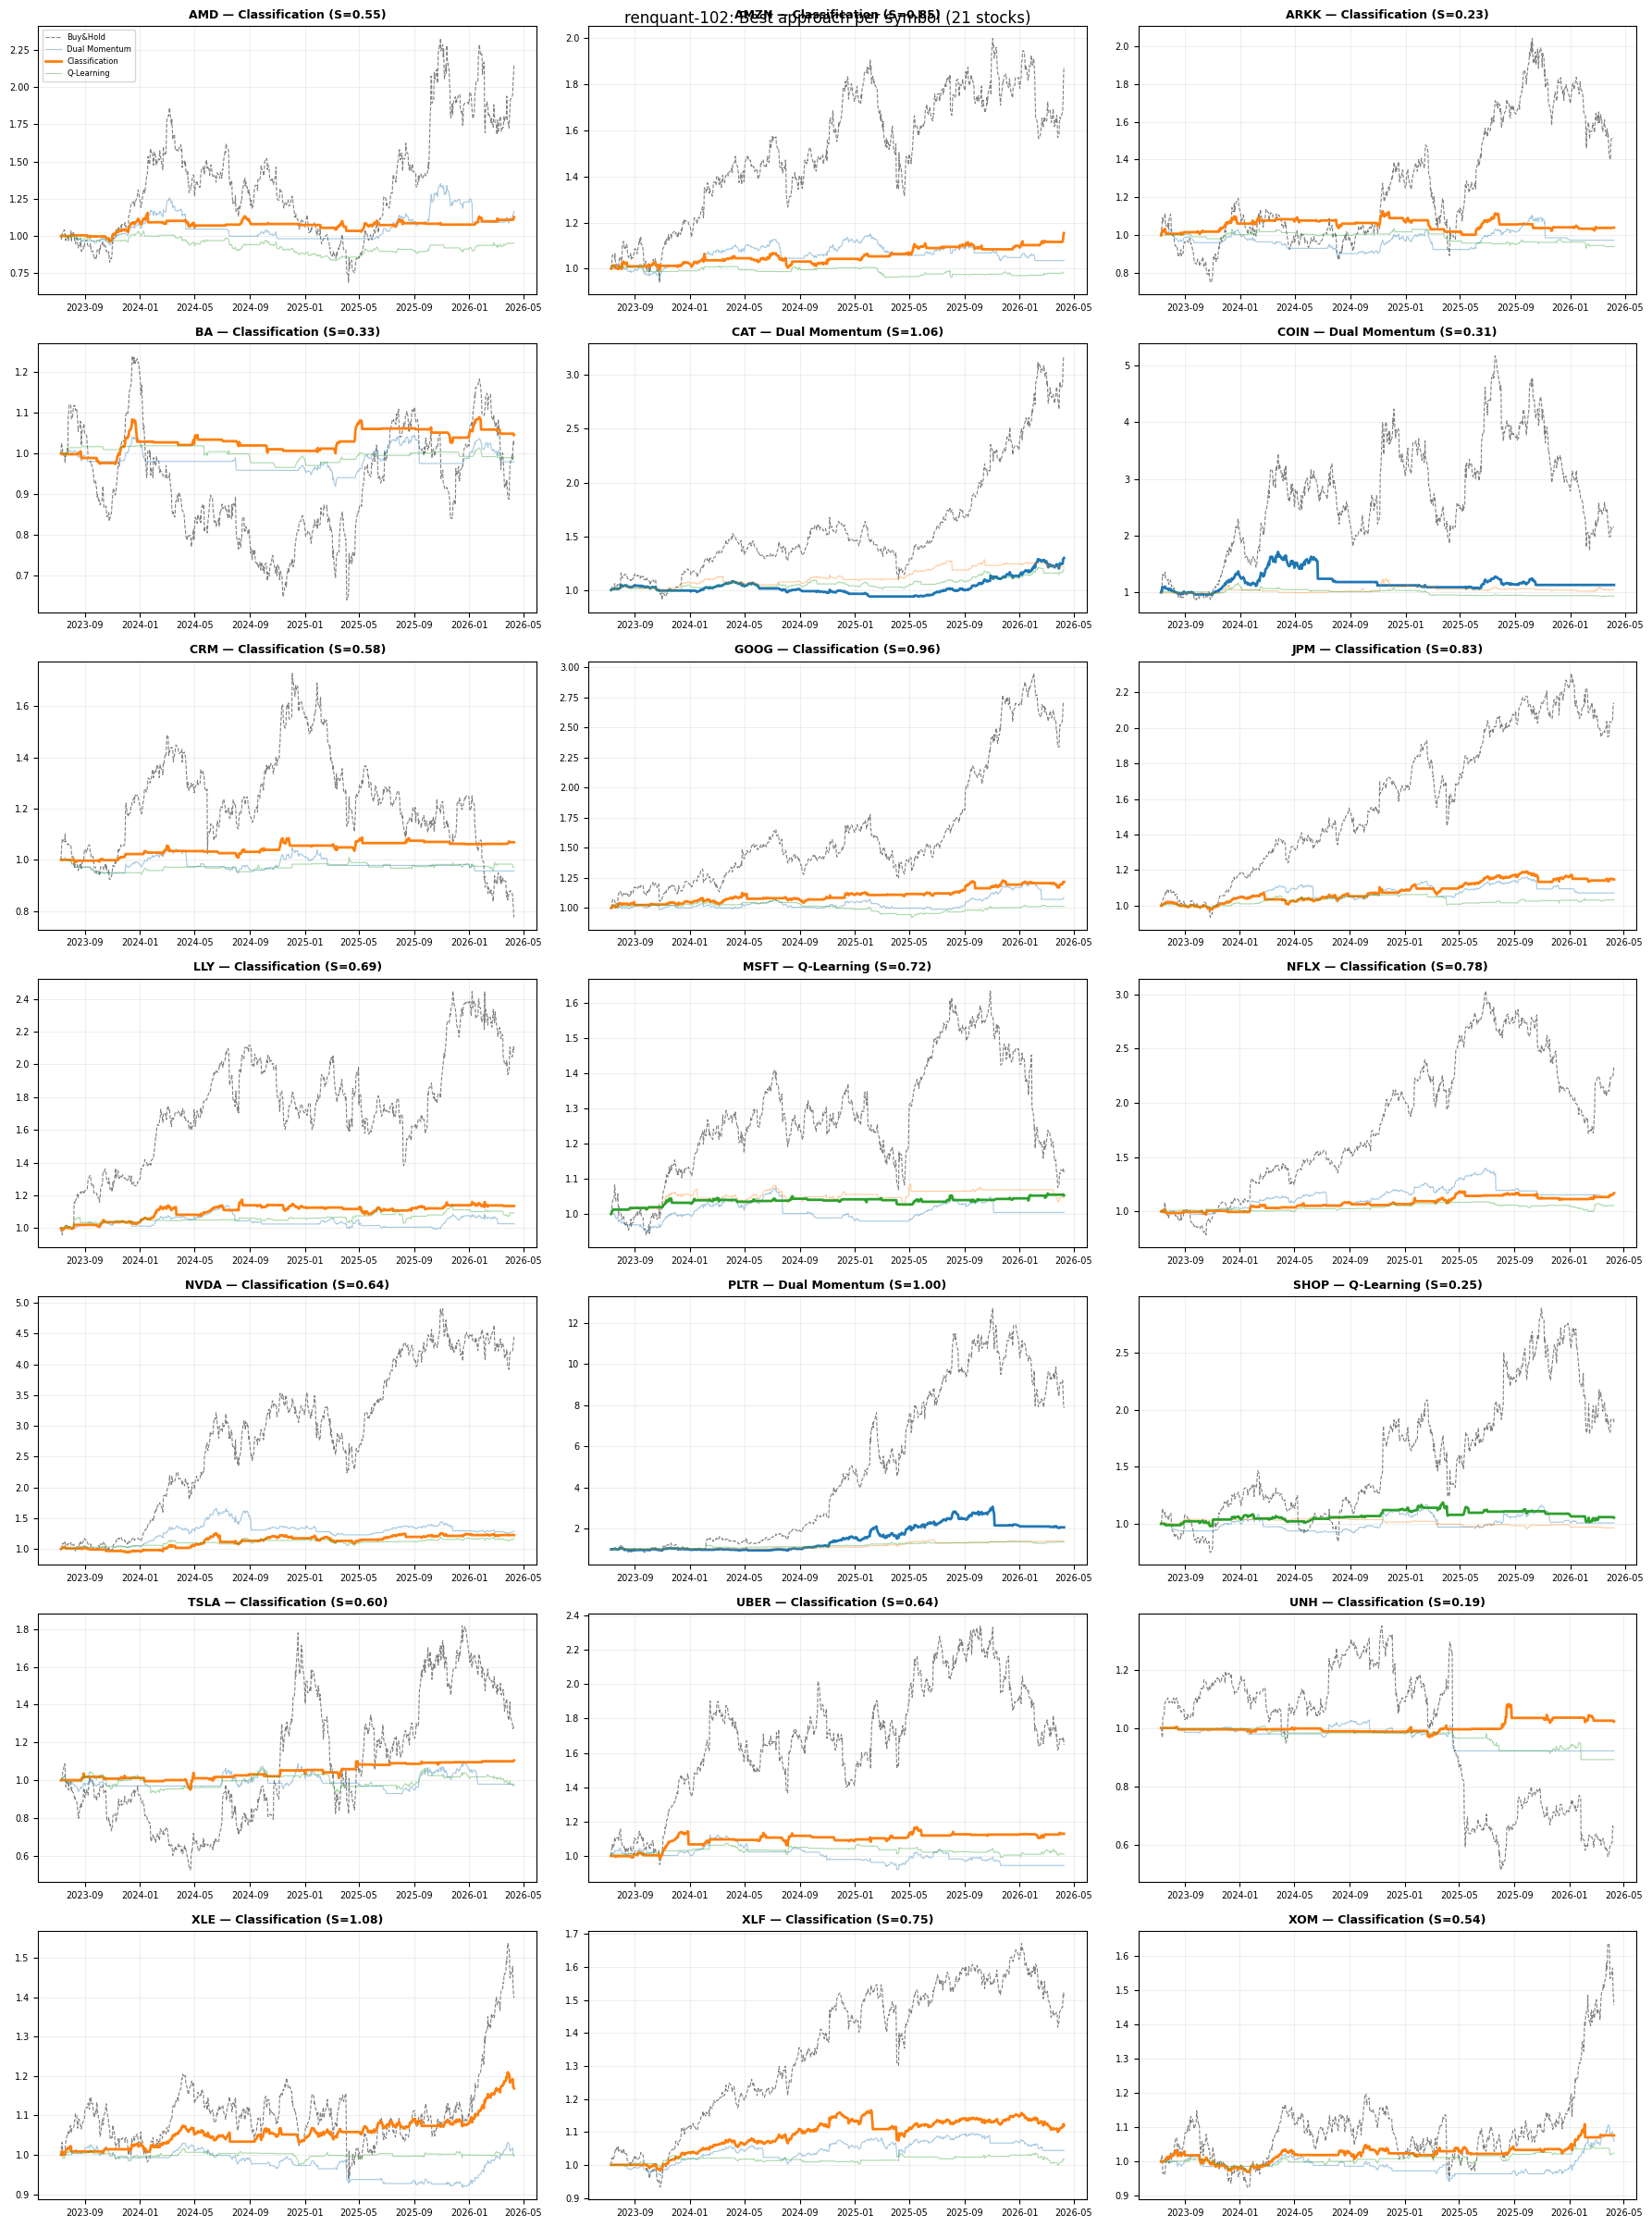

In [7]:
# ══════════════════════════════════════════════════════════════════════════
# Per-symbol comparison charts (compact grid)
# ══════════════════════════════════════════════════════════════════════════
symbols_sorted = sorted(results.keys())
n_symbols = len(symbols_sorted)
n_cols = 3
n_rows = (n_symbols + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows), sharex=False)
axes_flat = axes.flatten() if n_symbols > 1 else [axes]

approach_colors = {
    "Dual Momentum": "tab:blue",
    "Classification": "tab:orange",
    "Q-Learning": "tab:green",
}

for idx, symbol in enumerate(symbols_sorted):
    ax = axes_flat[idx]
    approaches = results[symbol]
    best_name = max(approaches, key=lambda k: approaches[k]["sharpe"])

    df = stock_features[symbol]
    bh = df["close"] / df["close"].iloc[0]
    ax.plot(bh.index, bh, color="gray", linestyle="--", linewidth=0.8, label="Buy&Hold")

    for name, ap in approaches.items():
        norm_eq = ap["equity"] / ap["equity"].iloc[0]
        lw = 2.0 if name == best_name else 0.8
        alpha = 1.0 if name == best_name else 0.4
        ax.plot(norm_eq.index, norm_eq, color=approach_colors[name],
                linewidth=lw, alpha=alpha, label=f"{name}")

    ax.set_title(f"{symbol} — {best_name} (S={approaches[best_name]['sharpe']:.2f})",
                 fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=6, loc="upper left")

# Hide unused axes
for idx in range(n_symbols, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(f"renquant-102: Best approach per symbol ({len(results)} stocks)", fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# ══════════════════════════════════════════════════════════════════════════
# Cross-symbol summary table
# ══════════════════════════════════════════════════════════════════════════
summary_rows = []
approach_wins = {}

for symbol in sorted(results.keys()):
    approaches = results[symbol]
    best_name = max(approaches, key=lambda k: approaches[k]["sharpe"])
    best = approaches[best_name]
    approach_wins[best_name] = approach_wins.get(best_name, 0) + 1

    hold_days = [(s - b).days for b, s, *_ in best["trades"]]
    summary_rows.append({
        "Symbol": symbol,
        "Best Approach": best_name,
        "Sharpe": round(best["sharpe"], 2),
        "Return": f"{best['return']:.1%}",
        "Round-trips": len(best["trades"]),
        "Avg Hold": f"{np.mean(hold_days):.0f}d" if hold_days else "-",
    })

# Add benchmark row
for symbol in sorted(results.keys()):
    df = stock_features[symbol]
    bh_ret = df["close"].iloc[-1] / df["close"].iloc[0] - 1

summary_df = pd.DataFrame(summary_rows).sort_values("Sharpe", ascending=False)

print("Approach win counts:")
for name, count in sorted(approach_wins.items(), key=lambda x: -x[1]):
    print(f"  {name:16s}: {count}")

print(f"\nTop 10 by Sharpe:")
summary_df.head(10)

Approach win counts:
  Classification  : 16
  Dual Momentum   : 3
  Q-Learning      : 2

Top 10 by Sharpe:


,Symbol,Best Approach,Sharpe,Return,Round-trips,Avg Hold
18,XLE,Classification,1.08,16.8%,6,93d
4,CAT,Dual Momentum,1.06,29.8%,5,79d
13,PLTR,Dual Momentum,1.00,107.3%,6,132d
7,GOOG,Classification,0.96,21.8%,13,42d
1,AMZN,Classification,0.85,15.4%,13,37d
8,JPM,Classification,0.83,14.8%,9,82d
11,NFLX,Classification,0.78,16.8%,18,20d
19,XLF,Classification,0.75,12.0%,1,501d
10,MSFT,Q-Learning,0.72,5.3%,23,9d
9,LLY,Classification,0.69,13.5%,14,37d


In [9]:
# Full summary table
print(f"All {len(summary_df)} symbols:")
summary_df

All 21 symbols:


,Symbol,Best Approach,Sharpe,Return,Round-trips,Avg Hold
18,XLE,Classification,1.08,16.8%,6,93d
4,CAT,Dual Momentum,1.06,29.8%,5,79d
13,PLTR,Dual Momentum,1.00,107.3%,6,132d
7,GOOG,Classification,0.96,21.8%,13,42d
1,AMZN,Classification,0.85,15.4%,13,37d
8,JPM,Classification,0.83,14.8%,9,82d
11,NFLX,Classification,0.78,16.8%,18,20d
19,XLF,Classification,0.75,12.0%,1,501d
10,MSFT,Q-Learning,0.72,5.3%,23,9d
9,LLY,Classification,0.69,13.5%,14,37d


# ══════════════════════════════════════════════════════════════════════════
# Portfolio-Level Simulation
# ══════════════════════════════════════════════════════════════════════════
# Replicate the LEAN multi-stock strategy logic in Python:
# - Scan volume z-scores daily (bullish days only: close > prev close)
# - Confirm with pre-trained model before entry (Sharpe floor = 0.5)
# - Manage up to 3 concurrent positions
# - Position sizing: max 30% per trade, 0% cash reserve
# - Starting capital: $100,000

In [10]:
# ── Portfolio simulation mirroring LEAN multi-stock strategy ──────────────
# Parameters — all read from strategy_config.json to stay in sync with LEAN
PORT_INITIAL_CASH = 100_000
PORT_MAX_POSITION_PCT = config.get("position_sizing", {}).get("max_position_pct", 0.30)
PORT_CASH_RESERVE_PCT = config.get("position_sizing", {}).get("cash_reserve_pct", 0.00)
PORT_MAX_POSITIONS = config.get("max_concurrent_positions", 5)
PORT_VOLUME_ZSCORE_LOOKBACK = config.get("volume_zscore_lookback", 20)
PORT_VOLUME_ZSCORE_THRESHOLD = config.get("volume_zscore_threshold", 1.5)
_vol_filter = config.get("volume_filter", {})
PORT_VOLUME_FILTER_MODE = _vol_filter.get("mode", "percentile")   # "percentile" or "zscore"
PORT_VOLUME_PERCENTILE_THRESHOLD = float(_vol_filter.get("percentile_threshold", 85))
PORT_WASH_SALE_DAYS = config.get("wash_sale_days", 30)
PORT_MIN_HOLD_DAYS = config.get("min_hold_days", 0)
PORT_MAX_HOLD_DAYS = config.get("max_hold_days", 0)
_risk = config.get("risk", {})
PORT_STOP_LOSS_PCT = -float(_risk.get("stop_loss_pct", 0.08))      # negative: -0.08 = exit at -8%
PORT_DRAWDOWN_HALT_PCT = float(_risk.get("portfolio_drawdown_halt_pct", 0.0))
_regime_cfg = _risk.get("regime_filter", {})
PORT_REGIME_FILTER = bool(_regime_cfg.get("enabled", False))
PORT_REGIME_SMA_PERIOD = int(_regime_cfg.get("sma_period", 200))
PORT_SECTOR_MAP = config.get("sector_map", {})
PORT_MAX_POSITIONS_PER_SECTOR = int(config.get("max_positions_per_sector", 0))

# ── Build a common trading calendar from SPY ─────────────────────────────
trading_days = dfs_raw[BENCHMARK].index.sort_values()

# ── Pre-compute volume scores for all stocks on all days ─────────────────
# LEAN percentile mode: score = % of last N days with lower volume (0-100)
# LEAN zscore   mode:  score = (today - mean) / std of last N days
volume_scores = {}  # {symbol: Series indexed by date}
_lookback = PORT_VOLUME_ZSCORE_LOOKBACK
for symbol in stock_features:
    if symbol not in dfs_raw:
        continue
    vol = dfs_raw[symbol]["volume"]
    if PORT_VOLUME_FILTER_MODE == "percentile":
        # Rolling window of lookback+1: last element is today, rest are history
        scores = vol.rolling(_lookback + 1, min_periods=_lookback + 1).apply(
            lambda w: (w[:-1] < w[-1]).sum() / len(w[:-1]) * 100, raw=True
        )
    else:
        vol_mean = vol.rolling(_lookback, min_periods=_lookback).mean().shift(1)
        vol_std  = vol.rolling(_lookback, min_periods=_lookback).std().shift(1)
        scores = (vol - vol_mean) / vol_std.replace(0, np.nan)
    volume_scores[symbol] = scores.dropna()

# ── Pre-compute daily price direction (bullish = close > prev close) ─────
price_up = {}  # {symbol: Series of bool indexed by date}
for symbol in stock_features:
    if symbol not in dfs_raw:
        continue
    close = dfs_raw[symbol]["close"]
    price_up[symbol] = close > close.shift(1)

# ── Pre-compute market regime (SPY SMA filter, period from config) ────────
_spy_close = dfs_raw[BENCHMARK]["close"]
_spy_sma = _spy_close.rolling(PORT_REGIME_SMA_PERIOD, min_periods=PORT_REGIME_SMA_PERIOD).mean()
market_bullish = (_spy_close > _spy_sma)  # True = SPY above its SMA → bull regime

# ── Get best model per symbol (same as export logic, with Sharpe floor) ──
MIN_SIM_SHARPE = 0.8
best_models = {}
for symbol in results:
    best_name = max(results[symbol], key=lambda k: results[symbol][k]["sharpe"])
    best = results[symbol][best_name]
    if best["sharpe"] < MIN_SIM_SHARPE:
        continue
    best_models[symbol] = {
        "name": best_name,
        "model": best["model"],
    }

print(f"Models passing Sharpe floor ({MIN_SIM_SHARPE}): {len(best_models)}/{len(results)}")

def model_predict_action(symbol, day_idx, df):
    """Get model action for a symbol on a given day using its feature frame."""
    model_obj = best_models[symbol]["model"]
    single = df.loc[[day_idx]]
    signals = model_obj.predict_bulk(single)
    return signals.iloc[0]

# ── Day-by-day portfolio simulation ──────────────────────────────────────
cash = float(PORT_INITIAL_CASH)
positions = {}       # {symbol: {"shares": int, "entry_date": date, "entry_price": float}}
last_sell_dates = {} # {symbol: date}

equity_history = []
trade_log = []

# High-water mark for drawdown circuit breaker
high_water_mark = float(PORT_INITIAL_CASH)
_skip_buys = False

# Trim sim_days to the last date all watchlist stocks have price data.
# sim_days is derived from SPY which may have data beyond other symbols.
_last_common = min(
    dfs_raw[s].index[-1] for s in dfs_raw if s != BENCHMARK
)
sim_days = trading_days[
    (trading_days >= trading_days[PORT_VOLUME_ZSCORE_LOOKBACK + 60]) &
    (trading_days <= _last_common)
]

for day in sim_days:
    # ── Mark-to-market ────────────────────────────────────────────────
    portfolio_value = cash
    for sym, pos in positions.items():
        if day in dfs_raw[sym].index:
            price = dfs_raw[sym].loc[day, "close"]
            if pd.notna(price):
                portfolio_value += pos["shares"] * price

    # ── Drawdown circuit breaker ──────────────────────────────────────
    high_water_mark = max(high_water_mark, portfolio_value)
    if PORT_DRAWDOWN_HALT_PCT > 0 and high_water_mark > 0:
        drawdown = (high_water_mark - portfolio_value) / high_water_mark
        _skip_buys = drawdown >= PORT_DRAWDOWN_HALT_PCT

    # ── Step 1: Process SELLS for held positions ──────────────────────
    for sym in list(positions.keys()):
        # Price-based exits only need dfs_raw; stock_features check deferred to model sell
        if day not in dfs_raw.get(sym, pd.DataFrame()).index:
            continue

        pos = positions[sym]
        days_held = (day - pos["entry_date"]).days
        price = dfs_raw[sym].loc[day, "close"]

        # Stop-loss (hard floor — bypasses min-hold constraint, matches LEAN)
        if PORT_STOP_LOSS_PCT < 0:
            unrealized_pct = (price / pos["entry_price"]) - 1
            if unrealized_pct <= PORT_STOP_LOSS_PCT:
                gross_pnl = (price - pos["entry_price"]) * pos["shares"]
                tax = common.compute_trade_tax(gross_pnl, days_held, **TAX_CONFIG)
                cash += pos["shares"] * price - tax
                trade_log.append({
                    "symbol": sym, "action": "sell", "date": day,
                    "price": price, "shares": pos["shares"],
                    "reason": f"stop_loss ({unrealized_pct:.1%}, {days_held}d)",
                    "pnl": gross_pnl, "tax": tax, "holding_days": days_held,
                })
                last_sell_dates[sym] = day
                del positions[sym]
                continue

        # Max hold forced sell
        if PORT_MAX_HOLD_DAYS > 0 and days_held >= PORT_MAX_HOLD_DAYS:
            gross_pnl = (price - pos["entry_price"]) * pos["shares"]
            tax = common.compute_trade_tax(gross_pnl, days_held, **TAX_CONFIG)
            cash += pos["shares"] * price - tax
            trade_log.append({
                "symbol": sym, "action": "sell", "date": day,
                "price": price, "shares": pos["shares"],
                "reason": f"max_hold ({days_held}d)",
                "pnl": gross_pnl, "tax": tax, "holding_days": days_held,
            })
            last_sell_dates[sym] = day
            del positions[sym]
            continue

        # Model-driven sell — needs indicator features
        if day not in stock_features.get(sym, pd.DataFrame()).index:
            continue  # No indicator data; price-based exits already checked
        if sym not in best_models:
            continue
        action = model_predict_action(sym, day, stock_features[sym])
        if action == "sell":
            # Min hold constraint
            if PORT_MIN_HOLD_DAYS > 0 and days_held < PORT_MIN_HOLD_DAYS:
                continue
            gross_pnl = (price - pos["entry_price"]) * pos["shares"]
            tax = common.compute_trade_tax(gross_pnl, days_held, **TAX_CONFIG)
            cash += pos["shares"] * price - tax
            trade_log.append({
                "symbol": sym, "action": "sell", "date": day,
                "price": price, "shares": pos["shares"],
                "reason": f"model_sell ({days_held}d)",
                "pnl": gross_pnl, "tax": tax, "holding_days": days_held,
            })
            last_sell_dates[sym] = day
            del positions[sym]

    # ── Step 2: Count open slots ──────────────────────────────────────
    open_slots = PORT_MAX_POSITIONS - len(positions)

    # ── Step 3: DETECT — scan volume scores (bullish only) ────────────
    # Regime gate + drawdown circuit breaker: skip new entries if either triggers
    regime_ok = (not PORT_REGIME_FILTER) or bool(market_bullish.get(day, False))
    if open_slots > 0 and regime_ok and not _skip_buys:
        candidates = []
        for sym in best_models:
            if sym in positions:
                continue
            if sym not in volume_scores or day not in volume_scores[sym].index:
                continue
            score = volume_scores[sym].loc[day]
            if np.isnan(score):
                continue
            # Volume trigger: percentile or zscore depending on mode
            if PORT_VOLUME_FILTER_MODE == "percentile":
                triggered = score >= PORT_VOLUME_PERCENTILE_THRESHOLD
            else:
                triggered = score >= PORT_VOLUME_ZSCORE_THRESHOLD
            if triggered:
                # Bullish filter: only enter on up-close days
                if sym in price_up and day in price_up[sym].index and not price_up[sym].loc[day]:
                    continue
                candidates.append((sym, score))

        # Rank by score descending (highest volume activity first)
        candidates.sort(key=lambda x: x[1], reverse=True)

        # ── Step 4: CONFIRM + EXECUTE ─────────────────────────────────
        for sym, score in candidates:
            if open_slots <= 0:
                break

            # Wash sale check
            if sym in last_sell_dates:
                if (day - last_sell_dates[sym]).days < PORT_WASH_SALE_DAYS:
                    continue

            # Sector concentration guard (matches LEAN sector_guard)
            if PORT_MAX_POSITIONS_PER_SECTOR > 0:
                sector = PORT_SECTOR_MAP.get(sym, "other")
                sector_count = sum(1 for s in positions if PORT_SECTOR_MAP.get(s, "other") == sector)
                if sector_count >= PORT_MAX_POSITIONS_PER_SECTOR:
                    continue

            # Model confirmation
            if day not in stock_features[sym].index:
                continue
            action = model_predict_action(sym, day, stock_features[sym])
            if action != "buy":
                continue

            # Position sizing
            portfolio_value = cash + sum(
                pos["shares"] * dfs_raw[s].loc[day, "close"]
                for s, pos in positions.items()
                if day in dfs_raw[s].index
            )
            cash_reserve = portfolio_value * PORT_CASH_RESERVE_PCT
            investable = max(cash - cash_reserve, 0)
            max_invest = portfolio_value * PORT_MAX_POSITION_PCT
            invest_amount = min(max_invest, investable)

            price = dfs_raw[sym].loc[day, "close"]
            shares = int(invest_amount // price)
            if shares <= 0:
                continue

            cash -= shares * price
            positions[sym] = {
                "shares": shares,
                "entry_date": day,
                "entry_price": price,
            }
            trade_log.append({
                "symbol": sym, "action": "buy", "date": day,
                "price": price, "shares": shares,
                "reason": f"vol_score={score:.1f}",
                "pnl": 0, "tax": 0, "holding_days": 0,
            })
            open_slots -= 1

    # ── Record daily equity ───────────────────────────────────────────
    eod_value = cash
    for sym, pos in positions.items():
        if day in dfs_raw[sym].index:
            _p = dfs_raw[sym].loc[day, "close"]
            if pd.notna(_p):
                eod_value += pos["shares"] * _p
    equity_history.append({"date": day, "equity": eod_value, "positions": len(positions), "cash": cash})

equity_df = pd.DataFrame(equity_history).set_index("date")
trade_df = pd.DataFrame(trade_log) if trade_log else pd.DataFrame()

print(f"Simulation: {sim_days[0].strftime('%Y-%m-%d')} -> {sim_days[-1].strftime('%Y-%m-%d')}")
print(f"Tax: short-term {TAX_CONFIG['short_term_rate']:.0%}, long-term {TAX_CONFIG['long_term_rate']:.0%}")
_mode_str = f"P{PORT_VOLUME_PERCENTILE_THRESHOLD:.0f}" if PORT_VOLUME_FILTER_MODE == "percentile" else f"Z{PORT_VOLUME_ZSCORE_THRESHOLD:.1f}"
print(f"Vol filter: {PORT_VOLUME_FILTER_MODE}({_mode_str}, lookback={PORT_VOLUME_ZSCORE_LOOKBACK})  |  "
      f"Regime: {'SPY>' + str(PORT_REGIME_SMA_PERIOD) + 'SMA' if PORT_REGIME_FILTER else 'off'}  |  "
      f"Stop-loss: {PORT_STOP_LOSS_PCT:.0%}  |  Drawdown halt: {PORT_DRAWDOWN_HALT_PCT:.0%}  |  "
      f"Max pos: {PORT_MAX_POSITIONS}  |  Sector guard: {PORT_MAX_POSITIONS_PER_SECTOR}/sector")
print(f"Total trades: {len(trade_df)}")
if len(trade_df) > 0:
    buys = trade_df[trade_df["action"] == "buy"]
    sells = trade_df[trade_df["action"] == "sell"]
    print(f"  Buys:  {len(buys)}")
    print(f"  Sells: {len(sells)}")
    total_gross = sells["pnl"].sum() if len(sells) > 0 else 0
    total_tax = sells["tax"].sum() if len(sells) > 0 else 0
    n_short = sum(1 for _, r in sells.iterrows() if r["holding_days"] < TAX_CONFIG["long_term_threshold_days"])
    n_long = len(sells) - n_short
    print(f"  Gross P&L (closed):     ${total_gross:,.2f}")
    print(f"  Tax paid:               ${total_tax:,.2f}  (ST: {n_short}, LT: {n_long})")
    print(f"  After-tax P&L (closed): ${total_gross - total_tax:,.2f}")
# Unrealized P&L on still-open positions
unrealized_gross = 0
for sym, pos in positions.items():
    sym_df = dfs_raw[sym]
    # Use last available close to avoid timestamp metadata mismatches
    available = sym_df.index[sym_df.index <= sim_days[-1]]
    if len(available) > 0:
        cur_price = sym_df.loc[available[-1], "close"]
        unrealized_gross += (cur_price - pos["entry_price"]) * pos["shares"]
if positions:
    open_detail = ", ".join(
        f"{s}({p['shares']}sh@{p['entry_price']:.2f})" for s, p in positions.items()
    )
    print(f"  Unrealized P&L (open {len(positions)} pos): ${unrealized_gross:,.2f}  [{open_detail}]")
print(f"Final equity: ${equity_df['equity'].iloc[-1]:,.2f}  (after tax)")
print(f"Return: {equity_df['equity'].iloc[-1] / PORT_INITIAL_CASH - 1:.2%}")


Models passing Sharpe floor (0.8): 6/21
Simulation: 2023-08-07 -> 2026-04-08
Tax: short-term 50%, long-term 32%
Vol filter: percentile(P85, lookback=20)  |  Regime: off  |  Stop-loss: -8%  |  Drawdown halt: 15%  |  Max pos: 5  |  Sector guard: 3/sector
Total trades: 60
  Buys:  31
  Sells: 29
  Gross P&L (closed):     $136,180.84
  Tax paid:               $58,387.61  (ST: 28, LT: 1)
  After-tax P&L (closed): $77,793.23
  Unrealized P&L (open 2 pos): $21,894.10  [CAT(51sh@342.55), XLE(1sh@44.49)]
Final equity: $199,687.33  (after tax)
Return: 99.69%


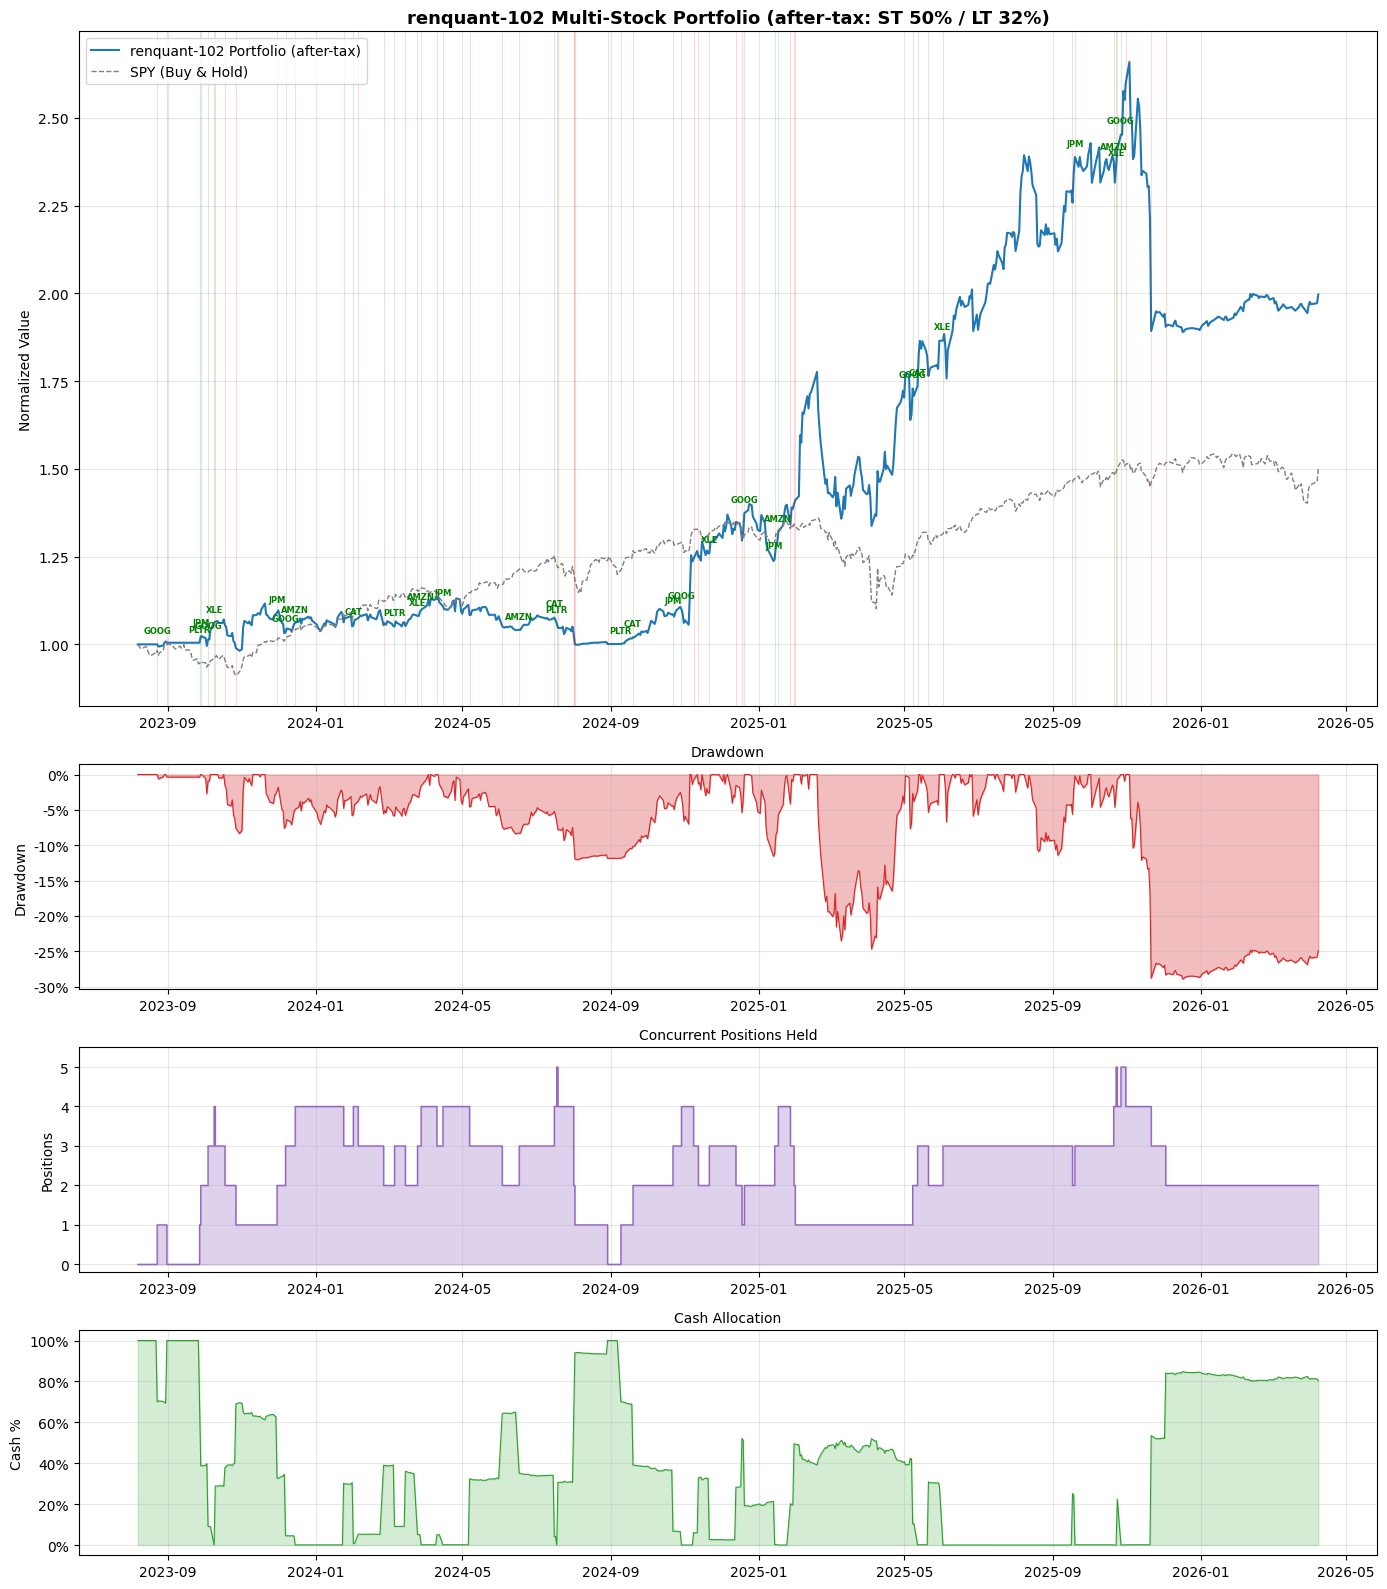


renquant-102  |  Aug 2023 → Apr 2026
                         Portfolio         SPY
  Return                     99.7%       50.0%
  Alpha                      49.7%
  Sharpe                      0.89
  Max Drawdown              -28.9%
  Win Rate                    69%  (20/29 trades)
──────────────────────────────────────────────────
  Realized P&L          $   +77,793  (-$58,388 tax)
  Unrealized P&L        $   +21,894  (2 open)
                          CAT 51sh @342.55 → 771.58 (+21,881, 331d)
                          XLE 1sh @44.49 → 58.05 (+14, 167d)
  Net P&L               $   +99,687


In [11]:
# ── Portfolio performance dashboard ─────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 16), gridspec_kw={"height_ratios": [3, 1, 1, 1]})

# Panel 1: Equity curve vs SPY benchmark
ax1 = axes[0]
norm_eq = equity_df["equity"] / PORT_INITIAL_CASH
spy_prices = dfs_raw[BENCHMARK].loc[equity_df.index, "close"]
norm_spy = spy_prices / spy_prices.iloc[0]

ax1.plot(norm_eq.index, norm_eq, color="tab:blue", linewidth=1.5, label="renquant-102 Portfolio (after-tax)")
ax1.plot(norm_spy.index, norm_spy, color="gray", linewidth=1, linestyle="--", label=f"{BENCHMARK} (Buy & Hold)")

# Mark buy/sell trades on equity curve
if len(trade_df) > 0:
    buys = trade_df[trade_df["action"] == "buy"]
    sells = trade_df[trade_df["action"] == "sell"]
    for _, t in buys.iterrows():
        if t["date"] in equity_df.index:
            ax1.axvline(t["date"], color="green", alpha=0.15, linewidth=0.8)
    for _, t in sells.iterrows():
        if t["date"] in equity_df.index:
            ax1.axvline(t["date"], color="red", alpha=0.15, linewidth=0.8)

# Annotate buy markers with symbol labels
if len(trade_df) > 0:
    for _, t in buys.iterrows():
        if t["date"] in equity_df.index:
            y = equity_df.loc[t["date"], "equity"] / PORT_INITIAL_CASH
            ax1.annotate(t["symbol"], xy=(t["date"], y), fontsize=6,
                         color="green", fontweight="bold", ha="center",
                         xytext=(0, 8), textcoords="offset points")

ax1.set_title(f"renquant-102 Multi-Stock Portfolio (after-tax: "
              f"ST {TAX_CONFIG['short_term_rate']:.0%} / LT {TAX_CONFIG['long_term_rate']:.0%})",
              fontsize=13, fontweight="bold")
ax1.set_ylabel("Normalized Value")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# Panel 2: Drawdown
peak = equity_df["equity"].cummax()
drawdown = (equity_df["equity"] - peak) / peak
ax2 = axes[1]
ax2.fill_between(drawdown.index, drawdown, 0, color="tab:red", alpha=0.3)
ax2.plot(drawdown.index, drawdown, color="tab:red", linewidth=0.8)
ax2.set_ylabel("Drawdown")
ax2.set_title("Drawdown", fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Panel 3: Number of positions held
ax3 = axes[2]
ax3.fill_between(equity_df.index, equity_df["positions"], 0, color="tab:purple", alpha=0.3, step="post")
ax3.step(equity_df.index, equity_df["positions"], color="tab:purple", linewidth=1, where="post")
ax3.set_ylabel("Positions")
ax3.set_title("Concurrent Positions Held", fontsize=10)
ax3.set_ylim(-0.2, PORT_MAX_POSITIONS + 0.5)
ax3.grid(True, alpha=0.3)

# Panel 4: Cash allocation
ax4 = axes[3]
cash_pct = equity_df["cash"] / equity_df["equity"]
ax4.fill_between(equity_df.index, cash_pct, 0, color="tab:green", alpha=0.2)
ax4.plot(equity_df.index, cash_pct, color="tab:green", linewidth=0.8)
if PORT_CASH_RESERVE_PCT > 0:
    ax4.axhline(PORT_CASH_RESERVE_PCT, color="orange", linestyle="--", linewidth=0.8,
                label=f"Reserve ({PORT_CASH_RESERVE_PCT:.0%})")
    ax4.legend(fontsize=8)
ax4.set_ylabel("Cash %")
ax4.set_title("Cash Allocation", fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

# ── Summary stats ────────────────────────────────────────────────────────
total_return = equity_df["equity"].iloc[-1] / PORT_INITIAL_CASH - 1
spy_return = norm_spy.iloc[-1] - 1
daily_rets = equity_df["equity"].pct_change().dropna()
rf_daily = 0.04 / 252  # 4% annual risk-free rate
sharpe = (daily_rets.mean() - rf_daily) / daily_rets.std() * np.sqrt(252) if daily_rets.std() > 0 else 0
max_dd = drawdown.min()

total_tax = 0
total_gross = 0
n_sells = 0
sells_df = pd.DataFrame()  # initialise so later code is safe on zero-trade runs
if len(trade_df) > 0:
    sells_df = trade_df[trade_df["action"] == "sell"]
    n_sells = len(sells_df)
    total_gross = sells_df["pnl"].sum()
    total_tax = sells_df["tax"].sum()

# Unrealized P&L on still-open positions (mark-to-market, pre-tax)
last_day = equity_df.index[-1]
unrealized_gross = 0
open_pos_detail = []
for sym, pos in positions.items():
    sym_df = dfs_raw[sym]
    available = sym_df.index[sym_df.index <= last_day]
    if len(available) > 0:
        cur_price = sym_df.loc[available[-1], "close"]
        if pd.isna(cur_price):
            cur_price = pos["entry_price"]  # fallback: treat as flat if price is NaN
        upnl = (cur_price - pos["entry_price"]) * pos["shares"]
        unrealized_gross += upnl
        days_open = (last_day - pos["entry_date"]).days
        open_pos_detail.append(
            f'{sym} {pos["shares"]}sh @{pos["entry_price"]:.2f} '
            f'→ {cur_price:.2f} ({upnl:+,.0f}, {days_open}d)'
        )

# Win rate
wins = int((sells_df["pnl"] > 0).sum()) if n_sells > 0 else 0
win_rate = wins / n_sells if n_sells > 0 else 0

sim_start = equity_df.index[0].strftime("%b %Y")
sim_end   = equity_df.index[-1].strftime("%b %Y")

print(f"\n{'='*50}")
print(f"renquant-102  |  {sim_start} → {sim_end}")
print(f"{'='*50}")
print(f"  {'':20s}  {'Portfolio':>10s}  {'SPY':>10s}")
print(f"  {'Return':20s}  {total_return:>10.1%}  {spy_return:>10.1%}")
print(f"  {'Alpha':20s}  {total_return - spy_return:>10.1%}")
print(f"  {'Sharpe':20s}  {sharpe:>10.2f}")
print(f"  {'Max Drawdown':20s}  {max_dd:>10.1%}")
print(f"  {'Win Rate':20s}  {win_rate:>9.0%}  ({wins}/{n_sells} trades)")
print(f"{'─'*50}")
at_pnl = total_gross - total_tax
total_tax_str = f"-${total_tax:,.0f} tax"
print(f"  {'Realized P&L':20s}  ${at_pnl:>+10,.0f}  ({total_tax_str})")
if positions:
    print(f"  {'Unrealized P&L':20s}  ${unrealized_gross:>+10,.0f}  ({len(positions)} open)")
    for detail in open_pos_detail:
        print(f"  {'':20s}    {detail}")
else:
    print(f"  {'Unrealized P&L':20s}  $          0.00  (no open positions)")
print(f"  {'Net P&L':20s}  ${at_pnl + unrealized_gross:>+10,.0f}")
print(f"{'='*50}")

In [12]:
# ── Trade log detail ──────────────────────────────────────────────────────
if len(trade_df) > 0:
    display_df = trade_df.copy()
    display_df["date"] = display_df["date"].dt.strftime("%Y-%m-%d")
    display_df["price"] = display_df["price"].map("${:,.2f}".format)
    display_df["pnl"] = display_df["pnl"].map("${:,.2f}".format)
    display_df["tax"] = display_df["tax"].map("${:,.2f}".format)
    display_df["tax_type"] = display_df["holding_days"].apply(
        lambda d: "LT" if d >= TAX_CONFIG["long_term_threshold_days"] else "ST"
    )
    print("Trade Log (after-tax):")
    display(display_df[["date", "symbol", "action", "shares", "price", "reason",
                        "holding_days", "pnl", "tax", "tax_type"]])
else:
    print("No trades executed — the volume z-score threshold was never met.")
    print(f"\nVolume z-score distribution (max per day across all stocks):")
    daily_max_zscores = []
    for day in sim_days:
        day_max = -999
        for sym in volume_zscores:
            if day in volume_zscores[sym].index:
                z = volume_zscores[sym].loc[day]
                if not np.isnan(z) and z > day_max:
                    day_max = z
        if day_max > -999:
            daily_max_zscores.append(day_max)

    zs = pd.Series(daily_max_zscores)
    print(f"  Mean:   {zs.mean():.2f}")
    print(f"  Median: {zs.median():.2f}")
    print(f"  P90:    {zs.quantile(0.90):.2f}")
    print(f"  P95:    {zs.quantile(0.95):.2f}")
    print(f"  P99:    {zs.quantile(0.99):.2f}")
    print(f"  Max:    {zs.max():.2f}")
    print(f"\n  Current threshold: {PORT_VOLUME_ZSCORE_THRESHOLD}")
    print(f"  Suggestion: try lowering to {zs.quantile(0.90):.1f} (P90) or {zs.quantile(0.80):.1f} (P80)")

Trade Log (after-tax):


,date,symbol,action,shares,price,reason,holding_days,pnl,tax,tax_type
0,2023-08-23,GOOG,buy,225,$133.21,vol_score=85.0,0,$0.00,$0.00,ST
1,2023-08-31,GOOG,sell,225,$137.35,model_sell (8d),8,$931.50,$465.75,ST
2,2023-09-27,PLTR,buy,2029,$14.85,vol_score=85.0,0,$0.00,$0.00,ST
3,2023-09-28,JPM,buy,208,$147.59,vol_score=85.0,0,$0.00,$0.00,ST
4,2023-10-04,GOOG,buy,223,$136.27,vol_score=90.0,0,$0.00,$0.00,ST
5,2023-10-09,XLE,buy,208,$44.29,vol_score=100.0,0,$0.00,$0.00,ST
6,2023-10-10,GOOG,sell,223,$139.20,model_sell (6d),6,$653.39,$326.69,ST
7,2023-10-18,XLE,sell,208,$45.98,model_sell (9d),9,$350.48,$175.24,ST
8,2023-10-27,JPM,sell,208,$135.69,"stop_loss (-8.1%, 29d)",29,"$-2,475.20",$0.00,ST
9,2023-11-30,JPM,buy,209,$156.08,vol_score=90.0,0,$0.00,$0.00,ST
